In [1]:
"""
CELL 1.
=========================================================================================
WHAT IS THIS CODE ABOUT?
This cell imports our data science libraries (Pandas, Matplotlib, Seaborn, and Scikit-Learn) 
and loads the clean 'transactions' dataset from our local SQLite database into memory.

WHY ARE WE DOING THIS?
Machine learning tools in Python work directly with Pandas DataFrames. By pulling from the 
SQLite database built in Week 1, we ensure we are starting Week 2 with cleaned data.

WHAT IS THE MAIN REASON BEHIND IT (INTENT)?
To maintain a clean separation between Week 1 (Data Engineering/ETL) and Week 2 (Data Science/EDA). 
This guarantees that any experimentation we do here will not affect the original database.

WHAT WILL BE THE RESULT?
A display of the first 5 rows of our dataset along with a structural summary (`df.info()`) 
showing column names, non-null counts, and data types.
=========================================================================================
"""

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Set global visual style for all plots
sns.set_theme(style="whitegrid")

# 1. Connect to SQLite database
conn = sqlite3.connect('fraud_detection.db')

# 2. Extract data into a DataFrame
df = pd.read_sql("SELECT * FROM transactions", conn)

# 3. Close the connection
conn.close()

# Display summary
display(df.head())
print(df.info())

,ssn,cc_num,first,last,gender,street,city,state,zip,lat,...,customer_avg_amout_1_day,customer_avg_amount_7_day,customer_avg_amount_30_day,merchant_num_trans_1_day,merchant_num_trans_7_day,merchant_num_trans_30_day,merchant_risk_1_day,merchant_risk_7_day,merchant_risk_30_day,merchant_risk_90_day
0,024-79-2449,30417925130692,Felicia,Gomez,F,486 Benson Stravenue,Rockford,IL,61107,42.2786,...,4.01,18.27,6.97,4824.23,73065.81,141799.95,4,13,20,14
1,269-54-1394,4224979584238239,Jeffrey,Mathews,M,5430 Leslie Flat Suite 854,Ceres,CA,95307,37.5833,...,88.83,77.27,8.06,3243.55,51496.77,1093950.50,3,10,11,28
2,527-16-1817,4056555304074394,Christina,Ellis,F,75933 Harvey Via Apt. 423,Buffalo,NY,14224,42.8371,...,66.96,67.47,43.41,4242.22,26384.49,1005859.33,6,14,23,48
3,314-98-4472,6011544296258081,Steven,Murphy,M,268 Anderson Valley Apt. 958,Mansfield Center,CT,6250,41.7698,...,15.32,58.22,52.05,4303.16,3476.36,226662.34,3,11,14,14
4,390-83-9961,374917808855764,Cynthia,Martinez,F,53164 Deborah Square Apt. 739,Anaheim,CA,92804,33.8186,...,28.81,44.64,24.65,2424.13,32215.14,36989.60,2,13,16,20


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 44 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ssn                         100000 non-null  object 
 1   cc_num                      100000 non-null  int64  
 2   first                       100000 non-null  object 
 3   last                        100000 non-null  object 
 4   gender                      100000 non-null  object 
 5   street                      100000 non-null  object 
 6   city                        100000 non-null  object 
 7   state                       100000 non-null  object 
 8   zip                         100000 non-null  int64  
 9   lat                         100000 non-null  float64
 10  long                        100000 non-null  float64
 11  city_pop                    100000 non-null  int64  
 12  job                         100000 non-null  object 
 13  dob            

C:\Users\USER\AppData\Local\Temp\ipykernel_3620\1099141397.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='is_fraud', palette='Set2')


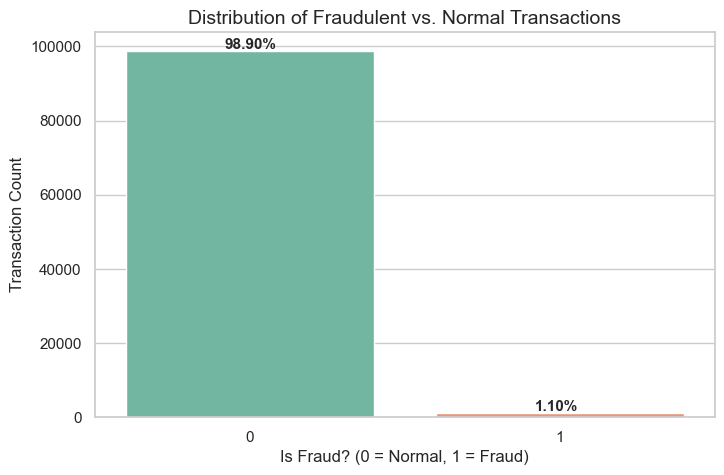

is_fraud
0    98897
1     1103
Name: count, dtype: int64


In [2]:
"""
CELL 2
=========================================================================================
WHAT IS THIS CODE ABOUT?
This cell creates a styled bar chart using Seaborn to show the total count and exact percentage 
of normal transactions (0) versus fraudulent transactions (1).

WHY ARE WE DOING THIS?
In real-world fraud detection, legitimate transactions drastically outnumber fraudulent ones. 
We need to know the exact proportion of fraud in our dataset before building models.

WHAT IS THE MAIN REASON BEHIND IT (INTENT)?
If 99% of the dataset is normal, an unadjusted model might simply predict "Not Fraud" 100% of 
the time and claim 99% accuracy while completely failing to catch actual fraud. Visualizing this 
helps the team understand why we must balance the data before training.

WHAT WILL BE THE RESULT?
A clear bar chart displaying the count of normal vs. fraudulent transactions with exact 
percentage annotations printed above each bar.
=========================================================================================
"""

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='is_fraud', palette='Set2')

# Calculate percentages and annotate bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x = p.get_x() + p.get_width() / 2 - 0.08
    y = p.get_height() + 500
    ax.annotate(percentage, (x, y), size=11, fontweight='bold')

plt.title('Distribution of Fraudulent vs. Normal Transactions', fontsize=14)
plt.xlabel('Is Fraud? (0 = Normal, 1 = Fraud)', fontsize=12)
plt.ylabel('Transaction Count', fontsize=12)
plt.show()

print(df['is_fraud'].value_counts())

In [3]:
print(df.columns.tolist())


['ssn', 'cc_num', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'acct_num', 'profile', 'trans_num', 'trans_date', 'trans_time', 'unix_time', 'category', 'amt', 'is_fraud', 'merchant', 'merch_lat', 'merch_long', 'customer_num_trans_1_day', 'customer_num_trans_7_day', 'customer_num_trans_30_day', 'trans_time_secs', 'trans_time_hrs', 'trans_time_is_night', 'trans_time_day', 'trans_date_is_weekend', 'customer_avg_amout_1_day', 'customer_avg_amount_7_day', 'customer_avg_amount_30_day', 'merchant_num_trans_1_day', 'merchant_num_trans_7_day', 'merchant_num_trans_30_day', 'merchant_risk_1_day', 'merchant_risk_7_day', 'merchant_risk_30_day', 'merchant_risk_90_day']


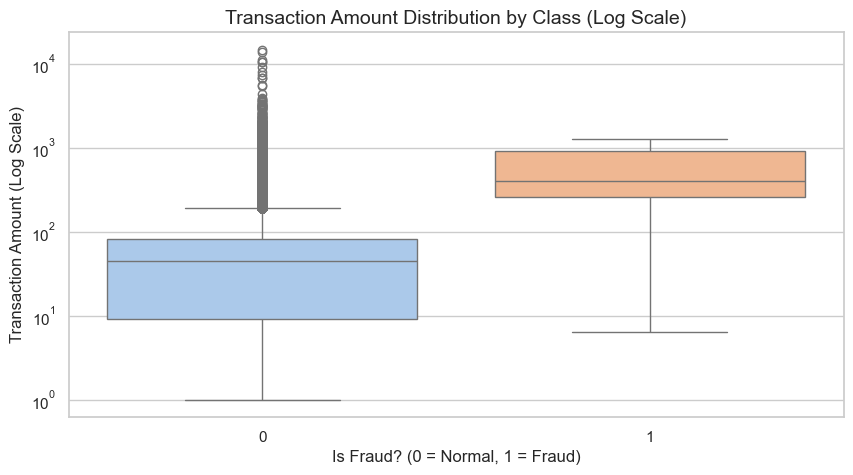

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,98897.0,68.180996,159.837462,1.00,9.05,44.46,81.36,14653.32
1,1103.0,534.247344,393.448223,6.38,262.03,397.55,922.67,1270.12


In [4]:
"""
CELL 3
=========================================================================================
WHAT IS THIS CODE ABOUT?
This cell generates a boxplot comparing transaction amounts for normal vs. fraudulent charges, 
using a logarithmic scale on the Y-axis. It also displays a statistical summary grouped by class.

WHY ARE WE DOING THIS?
We need to determine whether fraudulent transactions involve significantly higher or lower monetary 
amounts compared to normal transactions.

WHAT IS THE MAIN REASON BEHIND IT (INTENT)?
Transaction amounts usually have extreme differences (e.g., $5 coffee vs. $10,000 electronics). 
Applying `plt.yscale('log')` compresses the scale exponentially so we can clearly view both small 
and large transactions side-by-side without crushing the graph layout.

WHAT WILL BE THE RESULT?
A visual boxplot comparing medians, ranges, and outliers, followed by exact statistical metrics 
(mean, standard deviation, min, max) for both normal and fraudulent groups.
=========================================================================================
"""

plt.figure(figsize=(10, 5))

# Plot boxplot with log scale
sns.boxplot(data=df, x='is_fraud', y='amt', hue='is_fraud', palette='pastel', legend=False)
plt.yscale('log')

plt.title('Transaction Amount Distribution by Class (Log Scale)', fontsize=14)
plt.xlabel('Is Fraud? (0 = Normal, 1 = Fraud)', fontsize=12)
plt.ylabel('Transaction Amount (Log Scale)', fontsize=12)
plt.show()

# Display detailed statistics
display(df.groupby('is_fraud')['amt'].describe())

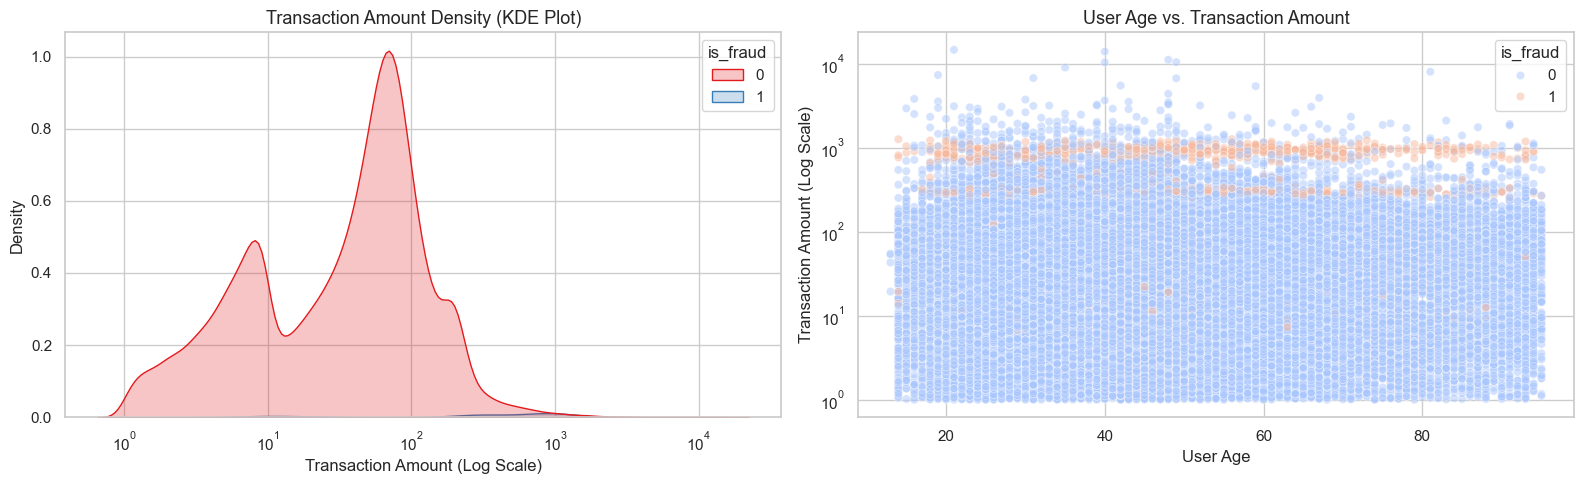

In [5]:
"""
CELL 4
=========================================================================================
WHAT IS THIS CODE ABOUT?
This cell generates two complementary visual charts: a Kernel Density Estimate (KDE) plot and 
a Scatter Plot to analyze how user age and transaction amounts interact across fraud classes.

Note :-  As 'age' is not mention as a column name in the file , I have to create the age by 
         using 'DOB' from the column name.

WHY ARE WE DOING THIS?
Boxplots show numerical summaries, but KDE plots show the exact shape and density curves of 
the data. Scatter plots help us visually see if fraudulent points cluster in specific age or 
amount ranges.

WHAT IS THE MAIN REASON BEHIND IT (INTENT)?
Giving your team intuitive, graphical views of the data makes it easy to explain patterns 
without getting bogged down in complex mathematical formulas.

WHAT WILL BE THE RESULT?
A side-by-side two-panel chart:
1. Smooth density curves highlighting transaction amount ranges where fraud is concentrated.
2. A scatter plot plotting transaction amount against user age, color-coded by fraud status.
=========================================================================================
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert date columns to datetime objects (if not already done)
df['dob'] = pd.to_datetime(df['dob'])
df['trans_date'] = pd.to_datetime(df['trans_date'])

# 2. Calculate 'user_age' in years at the time of the transaction
df['user_age'] = (df['trans_date'] - df['dob']).dt.days // 365

# 3. Now run your plotting code
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Density curve of transaction amounts
sns.kdeplot(data=df, x='amt', hue='is_fraud', fill=True, 
            palette='Set1', ax=axes[0], log_scale=True)
axes[0].set_title('Transaction Amount Density (KDE Plot)', fontsize=13)
axes[0].set_xlabel('Transaction Amount (Log Scale)')

# Panel 2: User Age vs. Transaction Amount Scatter Plot
sns.scatterplot(data=df, x='user_age', y='amt', hue='is_fraud', 
                alpha=0.5, palette='coolwarm', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('User Age vs. Transaction Amount', fontsize=13)
axes[1].set_xlabel('User Age')
axes[1].set_ylabel('Transaction Amount (Log Scale)')

plt.tight_layout()
plt.show()

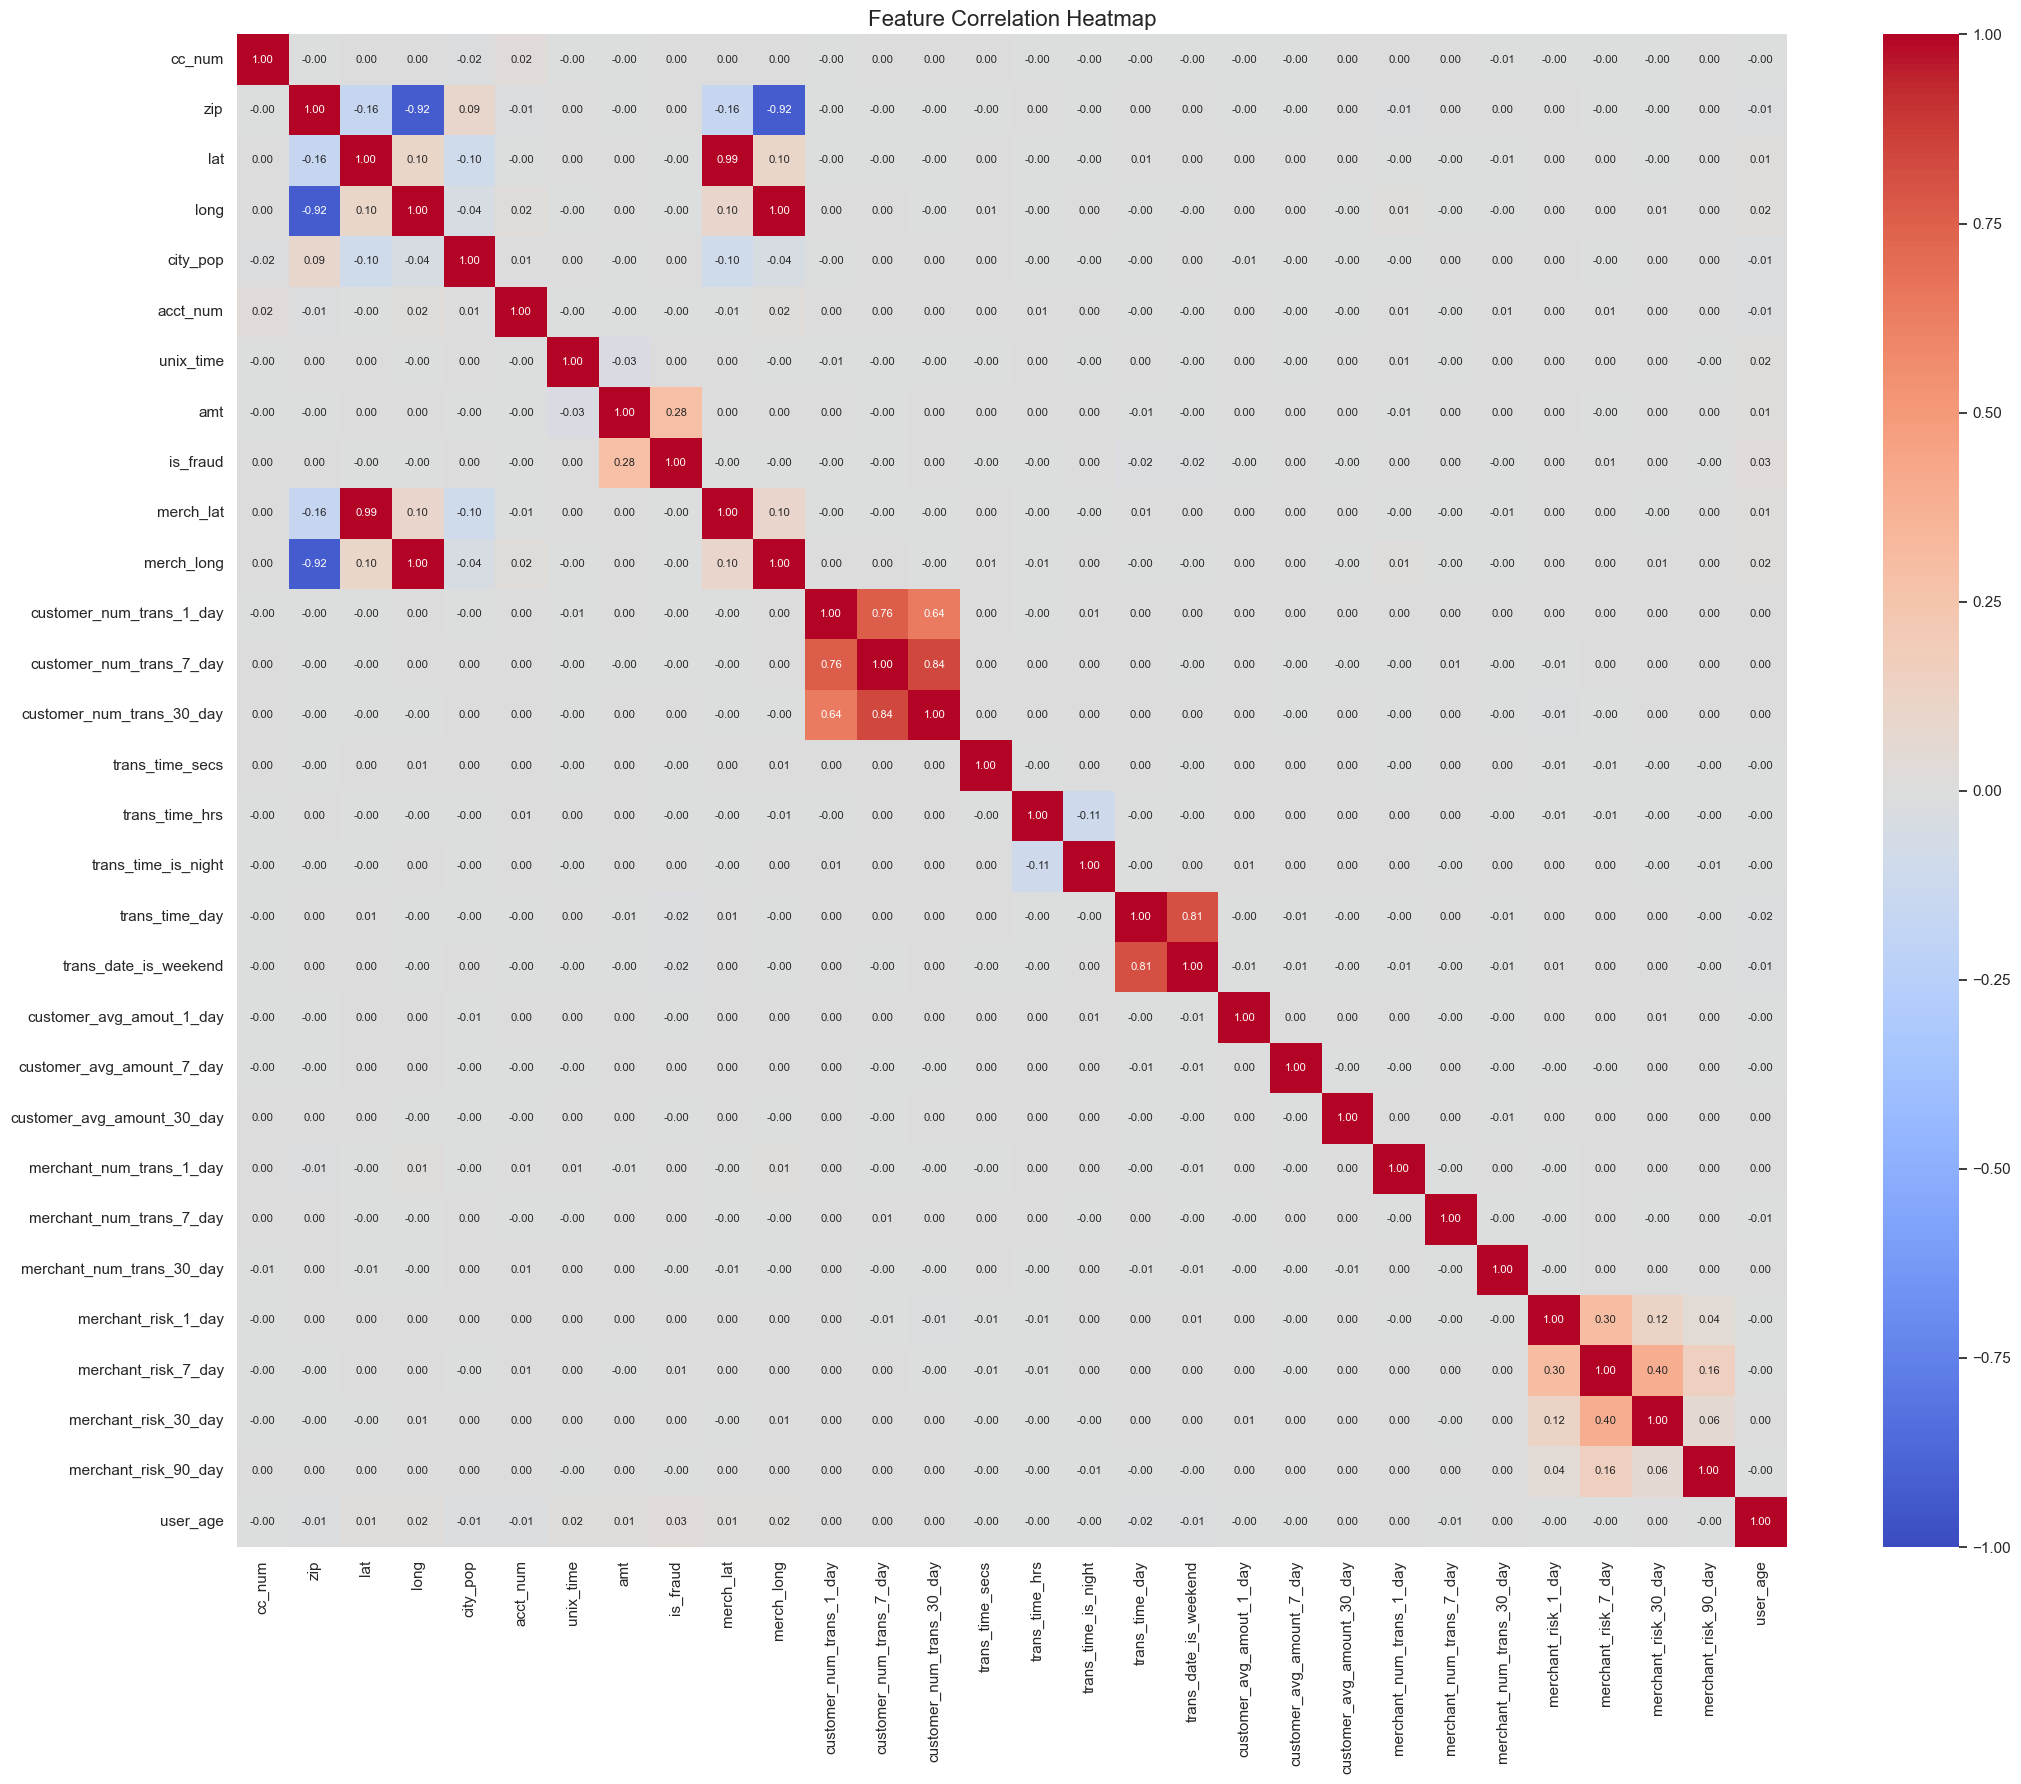

In [6]:
"""
CELL 5
=========================================================================================
WHAT IS THIS CODE ABOUT?
This cell isolates all numerical features in our dataset, calculates their correlation matrix, 
and displays the results using a Seaborn color-coded heatmap.

WHY ARE WE DOING THIS?
We need to see which numerical variables share strong relationships with `is_fraud`, as well 
as identify variables that are redundant (strongly correlated with each other).

WHAT IS THE MAIN REASON BEHIND IT (INTENT)?
If two features provide identical information (e.g., birth year and age), keeping both can 
confuse linear machine learning models. The heatmap allows us to quickly diagnose feature 
relationships visually.

WHAT WILL BE THE RESULT?
A color-coded correlation grid displaying numerical coefficients ranging from -1.0 (inverse 
relationship) to +1.0 (strong positive relationship).
=========================================================================================
"""

# 1. Significantly increase figure size so the grid has room to breathe
plt.figure(figsize=(22, 18))

# 2. Use 'number' to catch all numeric types (int32, int64, float32, float64)
numeric_df = df.select_dtypes(include='number')

# 3. Add annot_kws to shrink the font size of the numbers inside the boxes
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=-1, vmax=1, annot_kws={"size": 8})

plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
"""
CELL 6
=========================================================================================
WHAT IS THIS CODE ABOUT?
This cell safely processes categorical and numerical features. It selects only low-cardinality 
categorical features for One-Hot Encoding, drops high-cardinality text columns to prevent 
MemoryErrors, and standardizes continuous numbers using `StandardScaler`.

WHY ARE WE DOING THIS?
Columns like 'merchant' or 'job' have thousands of unique values. One-hot encoding them 
creates hundreds of thousands of empty columns, which crashes RAM with a MemoryError.

WHAT IS THE MAIN REASON BEHIND IT (INTENT)?
To transform categorical text into usable numeric flags without blowing up system memory, 
while ensuring all continuous features share a consistent numerical scale.

WHAT WILL BE THE RESULT?
A clean, memory-efficient encoded DataFrame containing numerical features ready for the 
train-test split.
=========================================================================================
"""

from sklearn.preprocessing import StandardScaler

# 1. Define explicit low-cardinality categorical columns to encode (avoiding high-cardinality ones like merchant/job)
categorical_cols = ['gender', 'category', 'state']

# Drop text/high-cardinality columns that are not needed or cause memory overflow
cols_to_drop = ['ssn', 'cc_num', 'first', 'last', 'street', 'city', 'zip', 'job', 
                'dob', 'acct_num', 'profile', 'trans_num', 'trans_date', 'trans_time', 'merchant']

# Clean DataFrame by dropping unused text columns first
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

# 2. Safe One-Hot Encoding on selected low-cardinality columns
df_encoded = pd.get_dummies(df_clean, columns=[c for c in categorical_cols if c in df_clean.columns], drop_first=True)

# 3. Feature Scaling (Standardization) on continuous columns
scaler = StandardScaler()
cols_to_scale = ['amt', 'customer_num_trans_1_day', 'customer_avg_amout_1_day', 'merchant_risk_1_day']

# Scale only columns that exist in the dataframe
existing_cols_to_scale = [col for col in cols_to_scale if col in df_encoded.columns]
df_encoded[existing_cols_to_scale] = scaler.fit_transform(df_encoded[existing_cols_to_scale])

# Display updated dataset info
display(df_encoded.head())
print("Safe Encoded Dataset Shape:", df_encoded.shape)

,lat,long,city_pop,unix_time,amt,is_fraud,merch_lat,merch_long,customer_num_trans_1_day,customer_num_trans_7_day,...,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY
0,42.2786,-89.0361,189162,1674907322,3.164681,0,42.135340,-89.171111,-0.502127,3,...,False,False,False,False,False,False,False,False,False,False
1,37.5833,-120.9496,42753,1657337351,-0.068664,0,36.664667,-120.679995,0.499044,9,...,False,False,False,False,False,False,False,False,False,False
2,42.8371,-78.7484,564824,1657620137,-0.085769,0,42.005869,-79.210680,-1.503298,1,...,False,False,False,False,False,False,False,False,False,False
3,41.7698,-72.2011,4821,1655612263,-0.031768,0,41.619398,-72.737010,-1.503298,5,...,False,False,False,False,False,False,False,False,False,False
4,33.8186,-117.9729,354475,1653959033,-0.196106,0,33.937114,-117.324680,-1.503298,0,...,False,False,False,False,False,False,False,False,False,False


Safe Encoded Dataset Shape: (100000, 91)


In [8]:
"""
CELL 7
=========================================================================================
WHAT IS THIS CODE ABOUT?
This cell divides our transformed dataset into two separate sets: 80% for Training and 20% for 
Testing, using stratified sampling.

WHY ARE WE DOING THIS?
Evaluating a model on the same data it was trained on leads to "overfitting" (memorization). 
Setting aside an unseen 20% test set allows us to measure how well the model generalizes to new data.

WHAT IS THE MAIN REASON BEHIND IT (INTENT)?
`stratify=y` ensures that both the training and testing sets maintain the exact same ratio of fraud 
to normal transactions, preventing the test set from receiving too few or too many fraud samples.

WHAT WILL BE THE RESULT?
Four distinct data splits (`X_train`, `X_test`, `y_train`, `y_test`) ready for model training setup.
=========================================================================================
"""

# Separate features (X) and target variable (y)
X = df_encoded.drop('is_fraud', axis=1)
y = df_encoded['is_fraud']

# Perform 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training Feature Shape (X_train): {X_train.shape}")
print(f"Testing Feature Shape (X_test): {X_test.shape}")
print(f"Training Target Class Distribution:\n{y_train.value_counts()}")

Training Feature Shape (X_train): (80000, 90)
Testing Feature Shape (X_test): (20000, 90)
Training Target Class Distribution:
is_fraud
0    79118
1      882
Name: count, dtype: int64


d:\ANACONDA\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\ANACONDA\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "d:\ANACONDA\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "d:\ANACONDA\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass

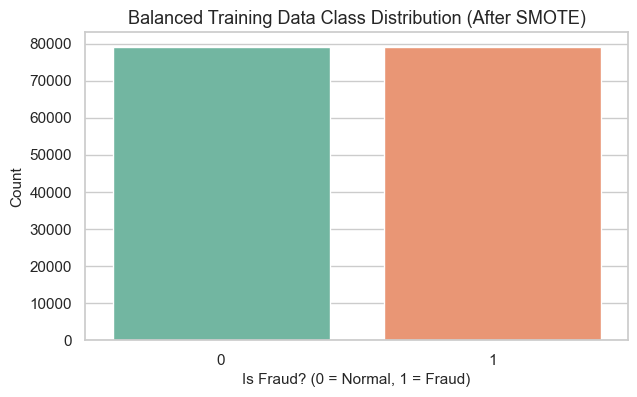

Original Training Distribution:
 is_fraud
0    79118
1      882
Name: count, dtype: int64

Resampled Training Distribution:
 is_fraud
0    79118
1    79118
Name: count, dtype: int64


In [9]:
"""
CELL 8
=========================================================================================
WHAT IS THIS CODE ABOUT?
This cell uses SMOTE (Synthetic Minority Over-sampling Technique) to balance the minority 
class (fraud) in the training data, and plots a simple bar chart of the resulting balanced classes.

WHY ARE WE DOING THIS?
Because normal transactions heavily dominate the dataset, models trained on raw data may struggle 
to learn fraud patterns. SMOTE creates synthetic variations of existing fraud examples to balance 
the classes during training.

WHAT IS THE MAIN REASON BEHIND IT (INTENT)?
Applying SMOTE *only* to the training set (`X_train`, `y_train`) prevents data leakage. The test 
set (`X_test`, `y_test`) remains untouched so we can evaluate model performance on real, un-augmented data.

WHAT WILL BE THE RESULT?
A balanced training target variable (`y_train_resampled`) with an equal 50/50 split between 
normal and fraud classes, confirmed by a bar chart visualization.
=========================================================================================
"""

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE strictly to the training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Plot balanced classes (added hue and legend=False for Seaborn compatibility)
plt.figure(figsize=(7, 4))
sns.countplot(x=y_train_resampled, hue=y_train_resampled, palette='Set2', legend=False)
plt.title('Balanced Training Data Class Distribution (After SMOTE)', fontsize=13)
plt.xlabel('Is Fraud? (0 = Normal, 1 = Fraud)', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.show()

print("Original Training Distribution:\n", y_train.value_counts())
print("\nResampled Training Distribution:\n", pd.Series(y_train_resampled).value_counts())

C:\Users\USER\AppData\Local\Temp\ipykernel_3620\4168690810.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='is_fraud', y='amt', palette='Set2')


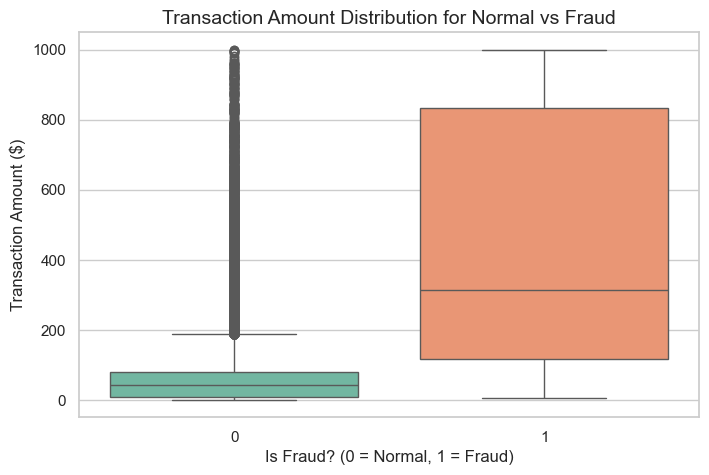

In [10]:
"""
CELL 9

WHAT IS THIS CODE?
This cell filters out extremely large transactions and creates a boxplot comparing 
the transaction amounts between normal and fraudulent activities.

WHY ARE WE DOING THIS? (WHY THIS CODE?)
Fraudulent transactions often have a different spending behavior than normal ones. 
Boxplots are excellent for visualizing the median, spread, and outliers of numerical data 
across different categories. We filter amounts under $1,000 because extreme outliers 
(like a single $50,000 transaction) will visually squash the rest of the chart, 
making it impossible to read.

WHAT IS THE IMPACT / RESULT?
The result will be a clear visual chart with two boxplots side-by-side. The impact is 
that we can visually prove to stakeholders whether fraudsters tend to make larger or 
smaller purchases compared to normal customers.
"""

# Filter the dataset to include only transactions less than $1,000 to remove chart-breaking outliers
df_filtered = df[df['amt'] < 1000]

# Set the size of the visualization
plt.figure(figsize=(8, 5))

# Generate the boxplot mapping the 'is_fraud' status to the transaction amount ('amt')
sns.boxplot(data=df_filtered, x='is_fraud', y='amt', palette='Set2')

# Add descriptive titles and labels for the report
plt.title('Transaction Amount Distribution for Normal vs Fraud', fontsize=14)
plt.xlabel('Is Fraud? (0 = Normal, 1 = Fraud)', fontsize=12)
plt.ylabel('Transaction Amount ($)', fontsize=12)

# Render the plot to the screen
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_3620\2461453207.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_fraud, x='trans_time_hrs', palette='Reds_r')


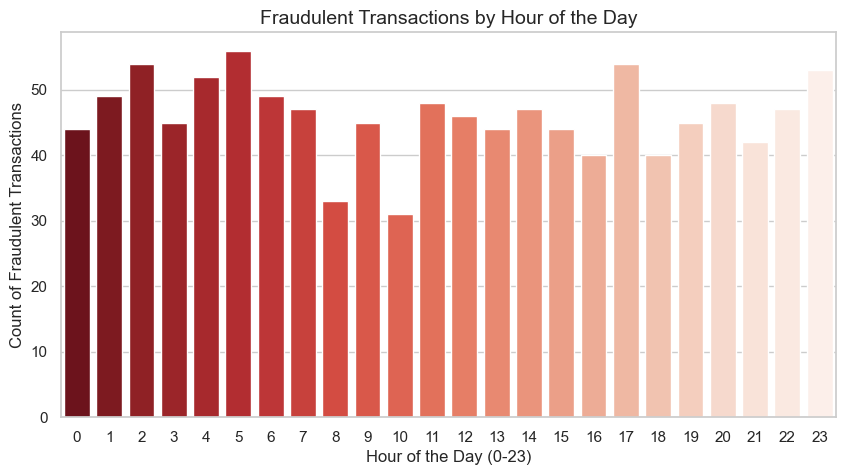

In [11]:
"""
CELL 10

WHAT IS THIS CODE?
This cell isolates only the fraudulent transactions and generates a count plot (bar chart) 
showing how many frauds occurred during each hour of a 24-hour day.

WHY ARE WE DOING THIS? (WHY THIS CODE?)
Time is often a major predictor of fraud. We want to see if fraudulent transactions peak 
during specific times (like late at night when people are sleeping). Using a countplot 
is the most effective way to aggregate and count occurrences across categorical/discrete 
time buckets (hours 0 through 23).

WHAT IS THE IMPACT / RESULT?
The result will be a bar chart displaying the frequency of fraud across the 24-hour clock. 
The impact is that if we spot a massive spike at 2:00 AM or 3:00 AM, our machine learning 
model will heavily rely on the 'time of day' feature to flag future transactions.
"""

# Create a new temporary dataframe containing ONLY fraudulent transactions
df_fraud = df[df['is_fraud'] == 1]

# Set the size of the visualization
plt.figure(figsize=(10, 5))

# Generate a countplot counting occurrences for each hour ('trans_time_hrs')
sns.countplot(data=df_fraud, x='trans_time_hrs', palette='Reds_r')

# Add descriptive titles and labels for the report
plt.title('Fraudulent Transactions by Hour of the Day', fontsize=14)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Count of Fraudulent Transactions', fontsize=12)

# Render the plot to the screen
plt.show()

In [12]:
"""
CELL 11

WHAT IS THIS CODE?
This cell prepares the data for machine learning and applies SMOTE (Synthetic Minority 
Oversampling Technique). It drops unusable columns, splits the data into training and 
testing sets, and then creates synthetic examples of fraud in the training set ONLY.

WHY ARE WE DOING THIS? (WHY THIS CODE?)
1. Dropping Columns: ML models require numeric data. Columns like credit card numbers or 
   zip codes are either non-numeric or act like unique IDs, which causes the model to memorize 
   rather than learn (overfitting).
2. Train/Test Split: We must separate our data into learning material (train) and a final 
   exam (test) to evaluate the model's true accuracy.
3. SMOTE: Because fraud only makes up ~1% of the data, a model could achieve 99% accuracy 
   just by guessing "Normal" every time. SMOTE generates synthetic "fake but mathematically accurate" 
   fraud data to balance the scales to 50/50.

WHAT IS THE IMPACT / RESULT?
The result will be console output showing the exact count of classes before and after SMOTE. 
The impact is that we prevent "Data Leakage" by applying SMOTE strictly to the training data. 
Our model will now be trained on a perfectly balanced dataset, allowing it to actually learn 
the patterns of fraud without being overwhelmed by the majority class.
"""

# Drop columns that are essentially unique IDs or non-generalizable to prevent overfitting
df_model = df.drop(columns=['cc_num', 'zip'])

# Keep only numeric data types, as machine learning algorithms process math, not text
df_numeric = df_model.select_dtypes(include=['int64', 'float64'])

# Separate the dataset into features (X - the clues) and the target variable (y - the answer key)
X = df_numeric.drop(columns=['is_fraud'])
y = df_numeric['is_fraud']

# Split data: 70% for training, 30% for testing. 
# 'stratify=y' ensures the original 1% fraud ratio is maintained in both splits initially.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Print the imbalance before applying SMOTE to prove the starting state
print("Training data shape BEFORE SMOTE:")
print(y_train.value_counts())

# Initialize and apply SMOTE ONLY to the training data (X_train, y_train) to prevent data leakage
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Print the balance after applying SMOTE to prove the training set is now 50/50
print("\nTraining data shape AFTER SMOTE:")
print(y_train_smote.value_counts())

Training data shape BEFORE SMOTE:
is_fraud
0    69228
1      772
Name: count, dtype: int64

Training data shape AFTER SMOTE:
is_fraud
0    69228
1    69228
Name: count, dtype: int64


In [15]:
# ==============================================================================
# CELL 12 : FILTER NUMERIC FEATURES, SMOTE, AND SAVE
# ==============================================================================
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. Separate Target (y) and Features (X)
# CHANGE 'is_fraud' to your actual target column name if it is different
y = df['is_fraud']

# 2. Extract ONLY numeric features (filters out IDs, SSNs, and text strings)
X = df.drop(columns=['is_fraud']).select_dtypes(include=['number'])

# 3. Split into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Apply SMOTE to balance numerical training data
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# 5. Save the balanced training data
pd.DataFrame(X_resampled, columns=X.columns).to_csv('X_train_balanced.csv', index=False)
pd.DataFrame(y_resampled).to_csv('y_train_balanced.csv', index=False)

# 6. Save the testing data
X_test.to_csv('X_test_final.csv', index=False)
y_test.to_csv('y_test_final.csv', index=False)

print("Success! Numeric features filtered, SMOTE applied, and files saved successfully.")

Success! Numeric features filtered, SMOTE applied, and files saved successfully.
